In [1]:
import matplotlib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def plot_violin_aggreg(df, equal=0.00, perc="%", rot=0, ha='center', figsize=(10, 6), file_name=None):
    sns.set(style="whitegrid", font_scale=1.1)
    plt.figure(figsize=figsize)
    
    ax = sns.violinplot(
        data=df,
        x="label",
        y="value",
        # hue="label",
        cut=0,
        density_norm='width',
        inner="quartile"
    )
    
    # plt.title("Relative Improvement vs 1L (Normalized to 100%)")
    plt.xlabel("")
    plt.ylabel("Improvement (%)")
    
    # Rotate x-axis labels
    plt.setp(ax.get_xticklabels(), rotation=rot, ha=ha)
    
    # Remove grid lines and spines
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)
    
    # Add a horizontal line at y=0
    ax.axhline(equal, color="black", linestyle="--", linewidth=1.5, alpha=0.8)
    # ax.text(ax.get_xlim()[1] + 0.1, equal, f"{equal:.2f}{perc}", va="center", ha="left", fontsize=9, fontweight="bold")
    
    # Find global max and min
    max_val = df["value"].max()
    min_val = df["value"].min()
    
    # Add horizontal lines for max and min
    ax.axhline(max_val, color="darkgreen", linestyle="-.", linewidth=1.5, alpha=0.8)
    ax.axhline(min_val, color="darkred", linestyle="-.", linewidth=1)
    
    # Add labels for max and min
    xpos = ax.get_xlim()[1] + 0.1  # position labels just outside the right edge
    ax.text(xpos, max_val, f"{max_val:.2f}{perc}", color="darkgreen", va="bottom", ha="left", fontsize=9, fontweight="bold")
    ax.text(xpos, min_val, f"{min_val:.2f}{perc}", color="darkred", va="top", ha="left", fontsize=9, fontweight="bold")
    
    plt.tight_layout()
    plt.show()

    if file_name:
        # Save as a high-resolution PNG
        ax.figure.savefig(
            file_name,
            dpi=600,               # 🔹 resolution (higher = sharper)
            bbox_inches="tight",   # 🔹 trims excess white space
            transparent=True       # 🔹 keeps background transparent
        )

def plot_violin_by_cores(df, equal=0.00, perc="%"):
    sns.set(style="whitegrid", font_scale=1.1)
    plt.figure(figsize=(10, 6))
    
    ax = sns.violinplot(
        data=df,
        x="system_cores",
        y="value",
        hue="label",
        cut=0,
        density_norm='width',
        inner="quartile"
    )
    
    # plt.title("Relative Improvement vs 1L (Normalized to 100%)")
    plt.xlabel("System Cores")
    plt.ylabel("Improvement (%)")
    plt.legend(title="System and Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Move legend to the top center
    ax.legend(
        title="",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.20),  # adjust height
        ncol=3,                      # display legend entries in one row
        frameon=False
    )
    
    # Remove grid lines and spines
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)
    
    # Add a horizontal line at y=0
    ax.axhline(equal, color="black", linestyle="--", linewidth=1.5, alpha=0.8)
    # ax.text(ax.get_xlim()[1] + 0.1, equal, f"{equal}{perc}", va="center", ha="left", fontsize=9)
    
    # Find global max and min
    max_val = df["value"].max()
    min_val = df["value"].min()
    
    # Add horizontal lines for max and min
    ax.axhline(max_val, color="darkgreen", linestyle="-.", linewidth=1.5, alpha=0.8)
    ax.axhline(min_val, color="darkred", linestyle="-.", linewidth=1)
    
    # Add labels for max and min
    xpos = ax.get_xlim()[1] + 0.1  # position labels just outside the right edge
    ax.text(xpos, max_val, f"{max_val:.2f}{perc}", color="darkgreen", va="bottom", ha="left", fontsize=9, fontweight="bold")
    ax.text(xpos, min_val, f"{min_val:.2f}{perc}", color="darkred", va="top", ha="left", fontsize=9, fontweight="bold")
    
    plt.tight_layout()
    plt.show()

def assign_levels(df, column="value", bins=None, labels=None):
    # Default: 5 evenly spaced bins between 0 and 1
    if bins is None:
        bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    if labels is None:
        labels = [f"Level {i}" for i in range(1, len(bins))]

    # Create the categorical level column
    df["level"] = pd.cut(df[column], bins=bins, labels=labels, include_lowest=True)

    # Count points per level
    counts = df["level"].value_counts().sort_index()

    # Compute percentages
    percentages = (counts / len(df)) * 100

    # Combine into a summary DataFrame
    summary = pd.DataFrame({
        "Level": counts.index,
        "Count": counts.values,
        "Percentage": percentages.values
    })

    return df, summary

In [3]:
path = './cleaned_all.csv'

group_by_columns = [
    'workflow_instance',
    'runtime_workflow_execs',
    'workflow_class',
    'system_name',
    'system_numa_domains',
    'system_cores',
    'algorithm_name', 
    'algorithm_mode',
    # 'file_name',
]

group_by_columns_numeric = [
    'durations_makespan',
    'algorithm_numa_awareness',
    'load_balance_numa_entropy',
    'load_balance_core_entropy',
    'durations_read_time_local_perc',
    'payloads_read_payload_local_perc',
    'accesses_read_accesses_local_perc',
    'ratios_comp_to_comm',
    'ratios_comm_to_comp',
    'runtime_data_pages_migrations',
    'runtime_data_pages_spreadings',
]

columns = group_by_columns + group_by_columns_numeric
columns_mean = group_by_columns_numeric
columns_std  = ['durations_makespan']

In [4]:
df = pd.read_csv(path)
df = df[columns]
df

,workflow_instance,runtime_workflow_execs,workflow_class,system_name,system_numa_domains,system_cores,algorithm_name,algorithm_mode,durations_makespan,algorithm_numa_awareness,load_balance_numa_entropy,load_balance_core_entropy,durations_read_time_local_perc,payloads_read_payload_local_perc,accesses_read_accesses_local_perc,ratios_comp_to_comm,ratios_comm_to_comp,runtime_data_pages_migrations,runtime_data_pages_spreadings
0,cycles-chameleon-1l-1c-12p-001,219,C,chameleon_compute_nvdimm,1,16,fifo,L,1.70981,0.000000,0.000000,0.999556,1.000000,1.000000,1.000000,0.206125,4.851436,0,0
1,cycles-chameleon-1l-1c-12p-001,219,C,chameleon_compute_nvdimm,1,16,fifo,L,1.70587,0.000000,0.000000,0.999556,1.000000,1.000000,1.000000,0.206116,4.851636,0,0
2,cycles-chameleon-1l-1c-12p-001,219,C,chameleon_compute_nvdimm,1,16,fifo,L,1.70875,0.000000,0.000000,0.999556,1.000000,1.000000,1.000000,0.206081,4.852454,0,0
3,cycles-chameleon-1l-1c-12p-001,219,C,chameleon_compute_nvdimm,1,16,fifo,L,1.70501,0.000000,0.000000,0.999556,1.000000,1.000000,1.000000,0.206631,4.839539,0,0
4,cycles-chameleon-1l-1c-12p-001,219,C,chameleon_compute_nvdimm,1,16,fifo,L,1.72448,0.000000,0.000000,0.999556,1.000000,1.000000,1.000000,0.206014,4.854044,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24272,epigenomics-chameleon-ilmn-6seq-50k-001,1695,S,chameleon_compute_nvdimm,4,8,min_min,N,27.87040,0.012077,0.999851,0.999894,0.609045,0.710253,0.710152,0.231225,4.324798,0,0
24273,epigenomics-chameleon-ilmn-6seq-50k-001,1695,S,chameleon_compute_nvdimm,4,8,min_min,N,28.03110,0.012492,0.999870,0.999901,0.596870,0.700291,0.700190,0.230047,4.346940,0,0
24274,epigenomics-chameleon-ilmn-6seq-50k-001,1695,S,chameleon_compute_nvdimm,4,8,min_min,N,28.07900,0.012729,0.999866,0.999893,0.590681,0.694553,0.694497,0.229229,4.362448,0,0
24275,epigenomics-chameleon-ilmn-6seq-50k-001,1695,S,chameleon_compute_nvdimm,4,8,min_min,N,28.00250,0.012117,0.999847,0.999893,0.607997,0.709261,0.709203,0.230304,4.342094,0,0


In [5]:
# Build aggregation dictionary
agg_dict = {col: 'mean' for col in columns_mean}
agg_dict.update({col: ['mean', 'std'] for col in columns_std})

# Perform grouped aggregation
df_avg = (
    df
    .groupby(group_by_columns)
    .agg(agg_dict)
    .reset_index()
)

# Flatten MultiIndex columns
df_avg.columns = [
    '_'.join([c for c in col if c]).strip('_') for col in df_avg.columns.to_flat_index()
]

df_avg

,workflow_instance,runtime_workflow_execs,workflow_class,system_name,system_numa_domains,system_cores,algorithm_name,algorithm_mode,durations_makespan_mean,durations_makespan_std,algorithm_numa_awareness_mean,load_balance_numa_entropy_mean,load_balance_core_entropy_mean,durations_read_time_local_perc_mean,payloads_read_payload_local_perc_mean,accesses_read_accesses_local_perc_mean,ratios_comp_to_comm_mean,ratios_comm_to_comp_mean,runtime_data_pages_migrations_mean,runtime_data_pages_spreadings_mean
0,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,1,8,fifo,L,2.899704,0.405880,0.000000,0.000000,0.988591,1.000000,1.000000,1.000000,0.293016,3.701295,0.0,0.0
1,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,1,8,fifo,R,3.488612,0.945634,0.500000,0.000000,0.999953,0.000000,0.000000,0.000000,0.226152,5.190490,0.0,0.0
2,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,1,8,heft,L,2.745898,0.489023,0.000000,0.000000,0.988629,1.000000,1.000000,1.000000,0.324672,3.342007,0.0,0.0
3,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,1,8,heft,R,3.566156,0.995952,0.500000,0.000000,1.000000,0.000000,0.000000,0.000000,0.222778,5.226978,0.0,0.0
4,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,1,8,min_min,L,3.013812,0.374982,0.000000,0.000000,0.999984,1.000000,1.000000,1.000000,0.255997,4.101189,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4959,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,4,24,fifo,N,0.904869,0.006556,0.024123,0.993887,0.996456,0.333683,0.429336,0.421053,0.152143,6.572887,0.0,0.0
4960,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,4,24,heft,A,1.034972,0.008525,0.025055,0.997130,0.996475,0.311413,0.406481,0.398684,0.148234,6.746740,0.0,0.0
4961,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,4,24,heft,N,0.998380,0.023953,0.029879,0.997576,0.996840,0.205952,0.282508,0.282895,0.145102,6.891965,0.0,0.0
4962,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,4,24,min_min,A,0.848368,0.002502,0.019737,0.993887,0.995846,0.441231,0.544003,0.526316,0.167887,5.956734,0.0,0.0


In [6]:
df_system_pivot = df_avg.pivot_table(
    index=['workflow_instance', 'runtime_workflow_execs', 'workflow_class', 'system_name', 'system_cores', 'algorithm_name'],
    columns=['system_numa_domains', 'algorithm_mode'],
    values=['durations_makespan_mean', 'durations_makespan_std'],
).reset_index()

# Flatten MultiIndex columns into readable labels
df_system_pivot.columns = [
    f"{col[1]}{col[2]}_mean" if col[0] == 'durations_makespan_mean' and col[2] != ''
    else f"{col[1]}{col[2]}_std" if col[0] == 'durations_makespan_std' and col[2] != ''
    else col[0]
    for col in df_system_pivot.columns.to_flat_index()
]

df_system_pivot

,workflow_instance,runtime_workflow_execs,workflow_class,system_name,system_cores,algorithm_name,1L_mean,1R_mean,2A_mean,2N_mean,4A_mean,4N_mean,1L_std,1R_std,2A_std,2N_std,4A_std,4N_std
0,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,8,fifo,2.899704,3.488612,2.973744,2.907937,NaN,NaN,0.405880,0.945634,0.763561,0.942023,NaN,NaN
1,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,8,heft,2.745898,3.566156,3.384932,3.280807,NaN,NaN,0.489023,0.995952,0.905164,0.867523,NaN,NaN
2,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,8,min_min,3.013812,3.511220,3.148904,2.954450,NaN,NaN,0.374982,0.897021,0.621630,0.631460,NaN,NaN
3,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,16,fifo,1.528270,1.872962,1.788224,1.678907,NaN,NaN,0.212804,0.461451,0.402233,0.432559,NaN,NaN
4,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,16,heft,1.323792,1.829158,1.713102,1.891612,NaN,NaN,0.229349,0.498447,0.435922,0.406739,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1055,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,16,heft,1.010812,1.421240,1.152562,1.152122,1.230082,1.290168,0.004834,0.005722,0.020694,0.008917,0.011218,0.011806
1056,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,16,min_min,0.953534,1.373828,1.053142,1.039220,1.078032,1.174966,0.002370,0.010196,0.026760,0.005413,0.008061,0.046534
1057,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,24,fifo,0.849024,1.220838,0.980986,0.884304,1.077852,0.904869,0.008248,0.026712,0.004649,0.012838,0.011047,0.006556
1058,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,24,heft,0.845948,1.187830,0.951295,0.971897,1.034972,0.998380,0.004093,0.015694,0.030705,0.023746,0.008525,0.023953


In [7]:
df_condition = (df_system_pivot['algorithm_name'] == 'fifo')
df_sample = df_system_pivot[df_condition]
df_summary = df_sample.reset_index(drop=True)
df_summary

,workflow_instance,runtime_workflow_execs,workflow_class,system_name,system_cores,algorithm_name,1L_mean,1R_mean,2A_mean,2N_mean,4A_mean,4N_mean,1L_std,1R_std,2A_std,2N_std,4A_std,4N_std
0,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,8,fifo,2.899704,3.488612,2.973744,2.907937,NaN,NaN,0.405880,0.945634,0.763561,0.942023,NaN,NaN
1,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,16,fifo,1.528270,1.872962,1.788224,1.678907,NaN,NaN,0.212804,0.461451,0.402233,0.432559,NaN,NaN
2,1000genome-chameleon-12ch-100k-001,312,C,chameleon_cascade_lake_r,24,fifo,1.175840,1.269656,1.363218,1.394685,NaN,NaN,0.147807,0.232387,0.307640,0.176252,NaN,NaN
3,1000genome-chameleon-12ch-100k-001,312,L,chameleon_cascade_lake_r,8,fifo,3.458880,4.569028,3.610313,4.381747,NaN,NaN,0.885087,1.558250,1.405555,1.377625,NaN,NaN
4,1000genome-chameleon-12ch-100k-001,312,L,chameleon_cascade_lake_r,16,fifo,1.798186,2.454972,2.055826,2.390922,NaN,NaN,0.397252,0.792906,0.663336,0.563077,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,srasearch-chameleon-50a-003,104,S,chameleon_cascade_lake_r,16,fifo,0.824242,0.940733,0.847985,0.954318,NaN,NaN,0.148657,0.273659,0.180132,0.137862,NaN,NaN
369,srasearch-chameleon-50a-003,104,S,chameleon_cascade_lake_r,24,fifo,0.716890,0.814461,0.880292,0.754241,NaN,NaN,0.136941,0.236214,0.092416,0.103182,NaN,NaN
370,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,8,fifo,1.530802,2.123094,1.838484,1.897966,1.882498,1.987144,0.003045,0.009068,0.002831,0.001772,0.004214,0.008557
371,srasearch-chameleon-50a-003,104,S,chameleon_compute_nvdimm,16,fifo,0.978390,1.392456,1.135268,1.094114,1.233128,1.275444,0.005023,0.021420,0.011556,0.006663,0.007559,0.012975


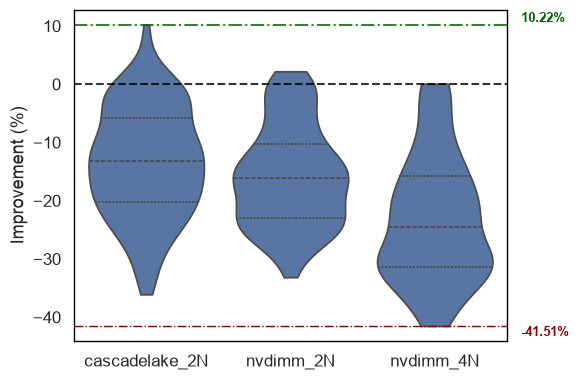

In [8]:
# Compute relative improvements using 1L as baseline

df_plot = df_summary.copy()
algorithm_mode = 'N'

df_plot[f"2{algorithm_mode}"] = 100 * (1 - df_plot[f"2{algorithm_mode}_mean"] / df_plot["1L_mean"])
df_plot[f"4{algorithm_mode}"] = 100 * (1 - df_plot[f"4{algorithm_mode}_mean"] / df_plot["1L_mean"])

# Keep only the systems of interest
df_plot = df_plot[df_plot["system_name"].isin(["chameleon_cascade_lake_r", "chameleon_compute_nvdimm"])]
df_plot["system_name"] = df_plot["system_name"].replace({"chameleon_cascade_lake_r": "cascadelake", "chameleon_compute_nvdimm": "nvdimm"})


# Melt for plotting
df_melt = pd.melt(
    df_plot,
    id_vars=["system_cores", "system_name", "workflow_instance"],
    value_vars=[f"2{algorithm_mode}", f"4{algorithm_mode}"],
    var_name="metric",
    value_name="value"
)

# Label systems + metric clearly
df_melt["label"] = df_melt.apply(
    lambda x: f"{x['system_name']}_{x['metric'].replace('_norm','')}",
    axis=1
)

# Remove NaN (no 4N/1L for cascade_lake_r)
df_melt = df_melt.dropna(subset=["value"])

# plot_violin_by_cores(df_melt, equal=0.00, perc="%")
plot_violin_aggreg(df_melt, equal=0.00, perc="%", figsize=(6,4), file_name="fifo_improvement.pdf")

In [9]:
bins = [-100, 0, 100] # boundaries for the 5 levels
labels = [
    "Negative [-100, 0]",
    "Positive (0, 100]",
]

df_levels, df_counts = assign_levels(df_melt, bins=bins, labels=labels)
df_counts

,Level,Count,Percentage
0,"Negative [-100, 0]",505,96.928983
1,"Positive (0, 100]",16,3.071017
